# 02 — Analytic Validation

Run the analytic validation harness (it invokes the native CLI) and show a pass/fail table plus the supporting plots:

1. **Drag-free ballistic** vs analytic parabola
2. **Terminal velocity** vs $v_\\mathrm{term}=\\sqrt{2mg/(\\rho C_d A)}$
3. **USSA76 atmosphere** vs published table values
4. **Noise-free proportional navigation** intercept (miss < 1 m)

In [1]:
import sys
from pathlib import Path

# Repo-relative imports (works whether run from repo root or notebooks dir).
REPO = Path.cwd()
while not (REPO / "build-native").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "postproc"))
sys.path.insert(0, str(REPO / "sensors"))

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [2]:
import pandas as pd
from gncpost.validate import run_all

results = run_all()
df = pd.DataFrame([{ 'check': r.name, 'result': 'PASS' if r.passed else 'FAIL',
                     'metric': r.metric, 'tolerance': r.tolerance,
                     'detail': r.detail } for r in results])
df

,check,result,metric,tolerance,detail
0,ballistic_parabola,PASS,0.000007,0.05,max |pos - analytic| = 0.007 mm over 15001 steps
1,terminal_velocity,PASS,0.004282,0.02,sim |vz|=41.16 m/s vs analytic 40.99 m/s (rho ...
2,ussa76_table,PASS,0.048346,0.05,"max table error 4.83% (0km:rho0.0%, 11km:rho0...."
3,pronav_intercept,PASS,0.000003,1.00,"intercept=True, miss_distance=0.00 cm"


In [3]:
assert all(r.passed for r in results), 'a validation check failed'
print('All analytic validation checks PASSED')

All analytic validation checks PASSED


## USSA76 density & temperature profile
The Python twin of the C++ atmosphere, overlaid with the published reference points used in the table check.

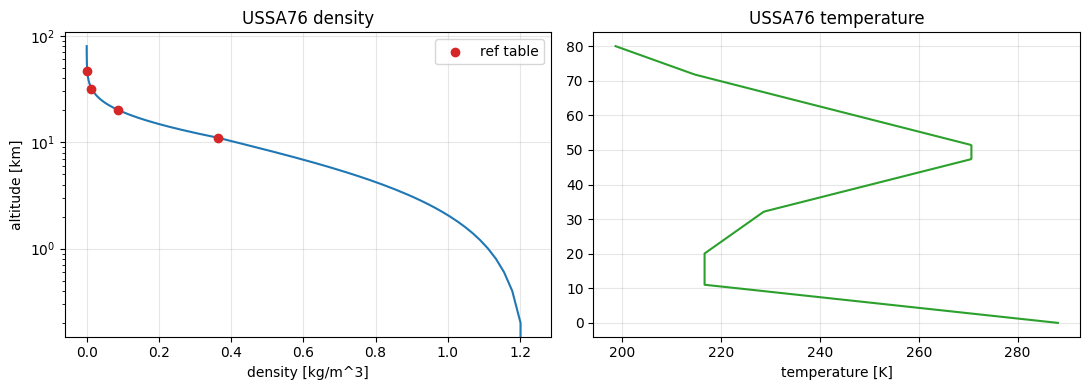

In [4]:
from gncpost.atmosphere import ussa76, REFERENCE_TABLE

alts = np.linspace(0, 80000, 400)
rho = [ussa76(a).density for a in alts]
T = [ussa76(a).temperature for a in alts]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
a0.semilogy(rho, alts/1000, color='#1f77b4'); a0.set_xlabel('density [kg/m^3]')
a0.set_ylabel('altitude [km]'); a0.set_title('USSA76 density'); a0.grid(alpha=0.3)
a0.scatter([REFERENCE_TABLE[a][1] for a in REFERENCE_TABLE],
           [a/1000 for a in REFERENCE_TABLE], color='#d62728', zorder=5, label='ref table')
a0.legend()
a1.plot(T, alts/1000, color='#2ca02c'); a1.set_xlabel('temperature [K]')
a1.set_title('USSA76 temperature'); a1.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Terminal-velocity convergence
A heavy body dropped from 2 km asymptotes to the closed-form terminal velocity.

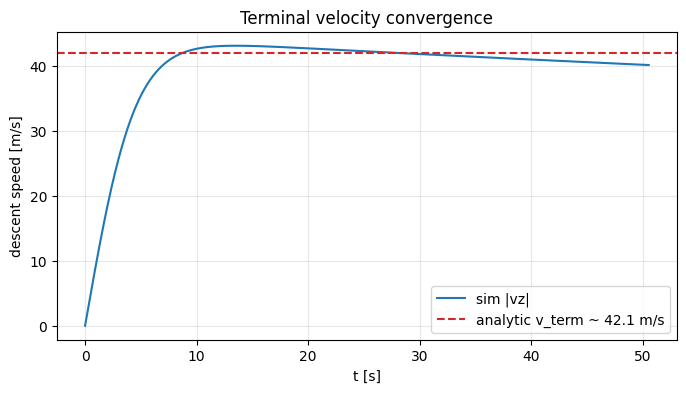

In [5]:
import tempfile, json
from pathlib import Path
from gncpost.loaders import run_cli, load_run
from gncpost.atmosphere import terminal_velocity

cfg = { 'scenario':'vt','model':'3dof','seed':1,'dt':0.002,'t_end':120.0,'integrator':'rk4',
  'env':{'g0':9.80665,'altitude_dependent_g':False,'atmosphere':True},
  'aero':{'ref_area':0.05,'cd_mach':[[0.0,1.0],[5.0,1.0]]},
  'vehicle':{'pos0':[0,0,2000],'launch_speed':0.001,'launch_elevation_deg':-90,
             'launch_azimuth_deg':0,'mass0':5.0},
  'guidance':{'law':'none'},'sensors':{'enable':False},
  'target':{'pos0':[9999999,0,0],'vel0':[0,0,0],'maneuver':'constant'} }
with tempfile.TemporaryDirectory() as td:
    p = Path(td)/'vt.json'; p.write_text(json.dumps(cfg))
    out = run_cli(p, Path(td)/'out'); veh = load_run(out).vehicle
vt = terminal_velocity(5.0,1.0,0.05, veh['z'].clip(lower=0).mean())
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(veh['t'], -veh['vz'], color='#1f77b4', label='sim |vz|')
ax.axhline(vt, color='#d62728', ls='--', label=f'analytic v_term ~ {vt:.1f} m/s')
ax.set_xlabel('t [s]'); ax.set_ylabel('descent speed [m/s]'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Terminal velocity convergence'); plt.show()